In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary
from networkx.classes import non_neighbors

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [2]:
design_matrix_test = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)

In [3]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)

In [4]:
design_matrix['temperature_ambulance'].min()

34.0

In [5]:
design_matrix_test['temperature_ambulance'].min()

32.0

In [6]:
design_matrix['survival_days'] = design_matrix['survival_days'].fillna(design_matrix['survival_days'].max())

In [7]:
design_matrix_test['survival_days'] = design_matrix_test['survival_days'].fillna(design_matrix_test['survival_days'].max())

In [8]:
design_matrix['organ_dysfunction'] = ((design_matrix[['sofa_score_increase_day1', 'sofa_score_increase_day2', 'sofa_score_increase_day3']] > 1).any(axis=1)).astype(int)
design_matrix_test['organ_dysfunction'] = ((design_matrix_test[['sofa_score_increase_day1', 'sofa_score_increase_day2', 'sofa_score_increase_day3']] > 1).any(axis=1)).astype(int)

In [9]:
design_matrix.shape

(680, 72)

In [10]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [11]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])

In [12]:
training_data['label'] = "training"
testing_data['label'] = "testing"

In [17]:
melted_data = training_data[continuous_clinical_columns].melt()

In [18]:
melted_data

,variable,value
0,sao2_ambulance,-0.440508
1,sao2_ambulance,-1.577464
2,sao2_ambulance,0.582753
3,sao2_ambulance,-1.008986
4,sao2_ambulance,-0.213116
...,...,...
7475,age,0.295378
7476,age,0.009216
7477,age,0.058323
7478,age,0.413090


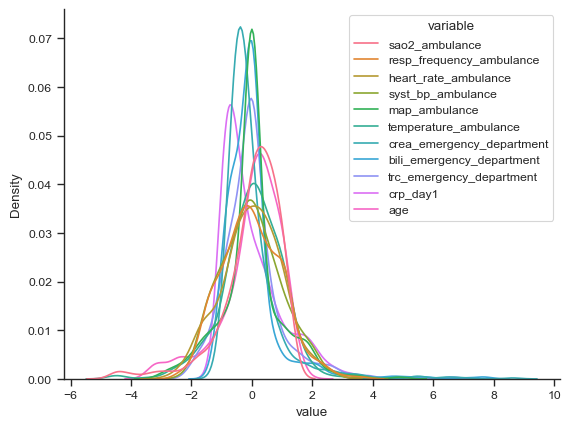

In [22]:
g = sns.kdeplot(
    data=melted_data,
    x="value",
    hue="variable",
)

g.get_figure().savefig(
    "clinical_col_distributions.png",
    dpi=300,
    transparent=True,
)